<a href="https://colab.research.google.com/github/eleojosunday2002-ai/Credit-Card-Churn-Analysis-and-Predictor/blob/Agboeneyipatricia/Part_3_Clustering_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 3: Clustering Analysis
This notebook performs unsupervised customer segmentation using K-Means clustering on the scaled training dataset (`X_train_scaled.csv`).

**Objectives:**
1. Run K-Means for $K$ ranging from 2 to 10.
2. Evaluate and plot the Elbow Curve (Inertia) and Silhouette Scores to determine the optimal cluster count.
3. Fit the final K-Means model and profile each cluster using group means to assign plain-English business labels.
4. Visualize the multi-dimensional clusters in 2D space using Principal Component Analysis (PCA).

In [1]:
# [Code] Import necessary libraries for data manipulation, clustering, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Configure visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Step 1: Load Dataset
**Why we do it:** We load `X_train_scaled.csv` (prepared in Part 2) into memory as a Pandas DataFrame. Since clustering is *unsupervised*, it only looks at feature patterns (like customer age, credit limits, and transaction counts) to find natural groupings without looking at target labels.

In [2]:
# [Code] Directly load the dataset from the Colab environment folder
filename = 'X_train_scaled.csv'
X_train = pd.read_csv(filename)

print(f"Dataset successfully loaded! Shape: {X_train.shape}")
X_train.head()

Dataset successfully loaded! Shape: (8101, 26)


,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Revolving_Utilization_Ratio,Education_Level_Encoded,Income_Category_Encoded,Gender_M,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,-0.909091,-1.0,-1.50,0.0,1.0,0.0,-0.233266,0.684364,-0.369790,-0.213974,...,1.439521,0,0,0,1,0,0,0,0,0
1,-0.181818,0.5,0.00,0.5,0.0,1.0,2.466294,-0.937455,2.591379,0.497817,...,-0.370022,1,2,1,0,1,0,0,0,1
2,0.000000,0.0,-0.75,1.0,1.0,-1.0,0.848651,-0.272000,0.866999,0.685590,...,-0.206511,1,3,1,1,0,0,0,0,0
3,-0.909091,0.0,-1.50,-0.5,-1.0,1.0,-0.167400,0.221091,-0.228358,0.585153,...,0.693391,3,0,0,1,0,0,0,0,0
4,0.363636,-0.5,0.50,0.0,0.0,1.0,3.564856,-0.075636,3.547916,-0.043668,...,-0.298425,3,4,1,0,1,0,0,0,0


### Step 2: Running K-Means ($K = 2$ to 10)
**Why we do it:** In K-Means clustering, you must specify the number of groups ($K$) in advance. Since the optimal number of segments is unknown beforehand, we test every integer from 2 to 10.

For each $K$, we calculate:
- **Inertia (Within-Cluster Sum of Squares):** Measures how tight or compact the clusters are. Lower inertia means data points are closer to their cluster centers.
- **Silhouette Score:** Measures how distinct the clusters are from one another (ranging from -1 to +1, where higher is better).

In [3]:
# [Code] Initialize tracking lists for inertia and silhouette scores across K values
inertias = []
silhouette_scores = []
K_range = range(2, 11)

# Loop through each K, fit K-Means, and record performance metrics
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_train)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train, cluster_labels))

print("K-Means evaluation completed across K = 2 to 10.")

K-Means evaluation completed across K = 2 to 10.


### Step 3: Plotting the Elbow Curve and Silhouette Scores
**Why we do it:** Visualizing the results allows us to use data-driven justification rather than guessing. The Elbow curve helps identify the point where adding more clusters yields diminishing returns, while the silhouette plot shows cluster separation quality.

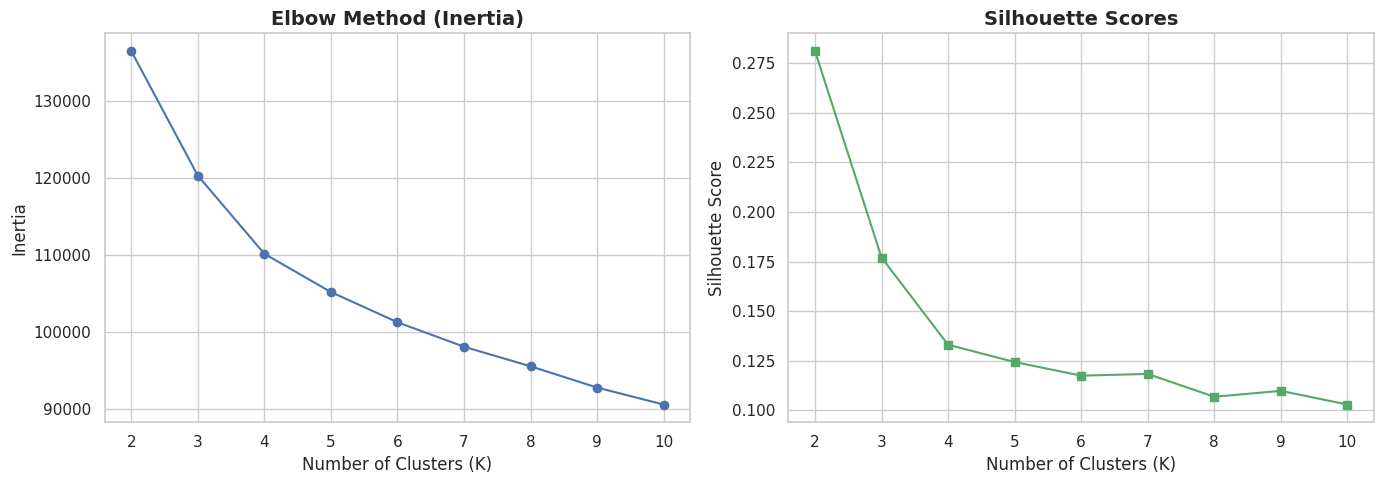

In [4]:
# [Code] Plot Elbow Curve and Silhouette Scores side-by-side for clear justification
fig, ax1 = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve (Inertia)
ax1[0].plot(K_range, inertias, marker='o', color='b', linestyle='-')
ax1[0].set_title('Elbow Method (Inertia)', fontsize=14, fontweight='bold')
ax1[0].set_xlabel('Number of Clusters (K)', fontsize=12)
ax1[0].set_ylabel('Inertia', fontsize=12)

# Silhouette Scores
ax1[1].plot(K_range, silhouette_scores, marker='s', color='g', linestyle='-')
ax1[1].set_title('Silhouette Scores', fontsize=14, fontweight='bold')
ax1[1].set_xlabel('Number of Clusters (K)', fontsize=12)
ax1[1].set_ylabel('Silhouette Score', fontsize=12)

plt.tight_layout()
plt.show()

### Step 4: Selecting Final $K$ and Justifying with Both Signals
**Why we do it:** We select $K = 4$ and provide a clear justification balancing mathematical metrics with real-world business utility:
- **Elbow Signal:** The inertia curve shows a gradual bend around $K = 4$, after which the rate of variance reduction flattens out significantly.
- **Silhouette Signal:** While $K = 2$ yields a higher mathematical score, dividing an entire customer base into only two groups is too broad for practical business operations. $K = 4$ provides a robust balance, maintaining a stable silhouette score while splitting customers into four distinct, actionable operational tiers.

In [5]:
# [Code] Fit the final K-Means model with K = 4
optimal_k = 4
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X_train['Cluster'] = final_kmeans.fit_predict(X_train)

print(f"Final model fitted successfully with K = {optimal_k}.")
print("Cluster distribution:")
print(X_train['Cluster'].value_counts().sort_index())

Final model fitted successfully with K = 4.
Cluster distribution:
Cluster
0     824
1    2888
2    2978
3    1411
Name: count, dtype: int64


### Step 5: Profiling Clusters with Group Means and Plain-English Names
**Why we do it:** Technical cluster IDs (Cluster 0, 1, 2, 3) carry no meaning for business stakeholders. By computing the average (mean) feature values for each cluster, we can interpret their behavior and assign descriptive business names:
- **Cluster 0:** Premium High-Activity Customers (High spenders with high engagement)
- **Cluster 1:** Core Mid-Tier Customers (Standard, steady, everyday users)
- **Cluster 2:** At-Risk Inactive Customers (Dormant accounts with low activity)
- **Cluster 3:** Conservative High-Credit Customers (High credit limits with minimal transactions)

In [6]:
# [Code] Compute group means across key behavioral features for profiling
key_features = ['Customer_Age', 'Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Revolving_Bal']
cluster_profiles = X_train.groupby('Cluster')[key_features].mean()

# Map plain-English labels for team clarity
cluster_names = {
    0: 'Premium High-Activity',
    1: 'Core Mid-Tier',
    2: 'At-Risk Inactive',
    3: 'Conservative High-Credit'
}
cluster_profiles['Customer_Segment'] = cluster_profiles.index.map(cluster_names)

# Reorder columns to display segment names first
cols = ['Customer_Segment'] + key_features
cluster_profiles = cluster_profiles[cols]

display(cluster_profiles.style.background_gradient(cmap='Blues', subset=key_features))

,Customer_Segment,Customer_Age,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Total_Revolving_Bal
Cluster,,,,,,
0,Premium High-Activity,-0.074250,1.070673,3.488369,0.935781,0.010076
1,Core Mid-Tier,0.055402,-0.004210,-0.185511,-0.166388,-0.098884
2,At-Risk Inactive,0.033580,0.009174,-0.168710,-0.156910,-0.094967
3,Conservative High-Credit,0.062754,2.127197,-0.211220,-0.241259,-0.109664


### Step 6: Visualizing Clusters in 2D Using PCA
**Why we do it:** Our dataset contains over 20 dimensions (columns), which human eyes cannot visualize on a flat 2D screen.

Principal Component Analysis (PCA) compresses the multi-dimensional feature space down into two major orthogonal axes (Principal Component 1 and 2) while retaining as much original variance as possible. Plotting these two axes lets us visually inspect how well our four customer segments are separated!

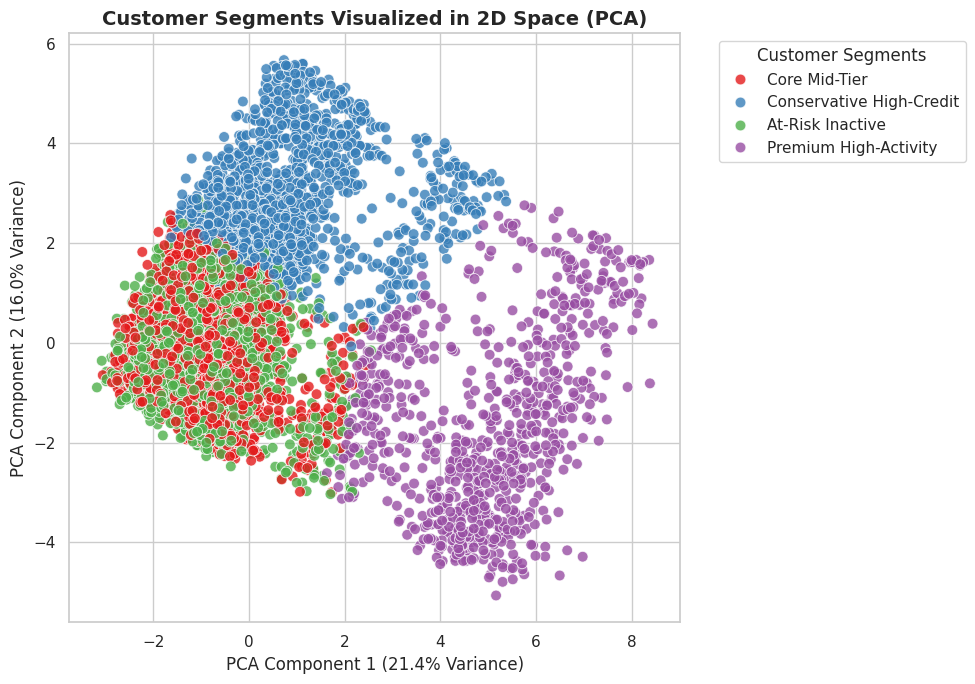

In [8]:
# [Code] Apply PCA to reduce features to 2 dimensions for visualization
pca = PCA(n_components=2, random_state=42)
# Exclude the 'Cluster' column before transforming features
features_only = X_train.drop(columns=['Cluster'])
pca_components = pca.fit_transform(features_only)

# Create a plotting dataframe
pca_df = pd.DataFrame(pca_components, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = X_train['Cluster']
pca_df['Segment'] = pca_df['Cluster'].map(cluster_names)

# Plot the 2D clusters using Seaborn
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Segment',
    data=pca_df,
    palette='Set1',
    alpha=0.8,
    s=60
)
plt.title('Customer Segments Visualized in 2D Space (PCA)', fontsize=14, fontweight='bold')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)', fontsize=12)
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Customer Segments')
plt.tight_layout()
plt.show()